In [1]:
import ultranest
import george
import numpy as np
import matplotlib.pyplot as plt
from ultranest.plot import cornerplot
from ultranest import ReactiveNestedSampler
from ultranest.plot import PredictionBand
from george.modeling import Model
from george import kernels, GP
from scipy.optimize import minimize

In [2]:
filename = 'Land_and_Ocean_complete.txt'
separator = "% Global Average Temperature Anomaly with Sea Ice Temperature Inferred from Water Temperatures"

with open(filename, 'r') as f:
    content = f.read()

parts = content.split(separator)

with open('data_air.txt', 'w') as f:
    f.write(parts[0])

with open('data_water.txt', 'w') as f:
    f.write(separator + parts[1])

data_air_raw = np.genfromtxt('data_air.txt', comments='%', filling_values=np.nan)
data_water_raw = np.genfromtxt('data_water.txt', comments='%', filling_values=np.nan)

print("File creati e caricati correttamente!")
def to_dict(raw):
    # Tempo in anni decimali: Anno + (Mese - 0.5)/12
    years = raw[:, 0]
    months = raw[:, 1]
    time_years = years + (months - 0.5) / 12
    t_ref = np.min(years)
    time_centered = time_years - t_ref
    return {
        "time_years": time_years,
        "time_centered": time_centered,
        "Year": raw[:,0].astype(int), 
        "Month": raw[:,1].astype(int), 
        "Monthly_Anomaly": raw[:,2], 
        "Monthly_Anomaly_Unc": raw[:,3], 
        "Annual_Anomaly": raw[:,4], 
        "Annual_Anomaly_Unc": raw[:,5], 
        "Five_Year_Anomaly": raw[:,6], 
        "Five_Year_Anomaly_Unc": raw[:,7], 
        "Ten_Year_Anomaly": raw[:,8], 
        "Ten_Year_Anomaly_Unc": raw[:,9], 
        "Twenty_Year_Anomaly": raw[:,10], 
        "Twenty_Year_Anomaly_Unc": raw[:,11], 
    }

data_air = to_dict(data_air_raw)
data_water = to_dict(data_water_raw)

print(f"Mesi caricati (Sezione Aria): {len(data_air['Year'])}")
print(f"Mesi caricati (Sezione Acqua): {len(data_water['Year'])}")

File creati e caricati correttamente!
Mesi caricati (Sezione Aria): 2100
Mesi caricati (Sezione Acqua): 2100


In [3]:
def constant_model(t, intercept):
    return intercept + t*0

def linear_model(t, a, b):
    return b + a*t

def quadratic_model(t, a, b, c):
    return c + b*t + a*t**2

def exponential_model(t, a, b, c):
    return a * np.exp(b*t) + c

In [23]:
param_constant = ['intercept']
param_linear = ['a', 'b']
param_quadratic = ['a', 'b', 'c']
param_exponential = ['a', 'b', 'c']

def prior_constant(cube):

    params = cube.copy()

    params[0] = cube[0] * 10 - 5

    return params

def prior_linear(cube):

    params = cube.copy()

    params[0] = cube[0] * 10
    params[1] = cube[1] * 10 - 5

    return params

def prior_quadratic(cube):

    params = cube.copy()

    params[0] = cube[0] * 2 - 1
    params[1] = cube[1] * 10 - 5
    params[2] = cube[2] * 10 - 5

    return params

def prior_exponential(cube):

    params = cube.copy()

    params[0] = cube[0] * 2.0
    params[1] = cube[1] * 0.05
    params[2] = cube[2] * 10 - 5
    
    return params

def log_likelihood_constant(params, data):
    
    intercept = params

    model = constant_model(data['time_centered'], intercept)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_linear(params, data):
    
    a, b = params

    model = linear_model(data['time_centered'], a, b)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2)

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_quadratic(params, data):
    
    a, b, c = params

    model = quadratic_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_exponential(params, data):
    
    a, b, c = params

    model = exponential_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

In [ ]:
datasets = {
    'air': data_air,
    'water': data_water
}

models_config = {
    'const': (param_constant, log_likelihood_constant, prior_constant),
    'linear': (param_linear, log_likelihood_linear, prior_linear),
    'quadratic': (param_quadratic, log_likelihood_quadratic, prior_quadratic),
    'exponential': (param_exponential, log_likelihood_exponential, prior_exponential),
}

results = {}
samplers = {}

for model_label, (params, loglike_fn, prior_fn) in models_config.items():
    for data_label, data in datasets.items():
        
        run_id = f"{data_label}_{model_label}" 
        print(f"STARTING RUN: {run_id.upper()}")
        
        sampler = ReactiveNestedSampler(
            params, 
            lambda p, d=data: loglike_fn(p, d), 
            prior_fn
        )
        
        res = sampler.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

        samplers[run_id] = sampler
        results[run_id] = res
        
        print(f"\nDONE: {run_id}")
        sampler.print_results()

In [ ]:
fig = plt.figure(figsize=(16, 12))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.2, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_const'], fig=corner_subfigs[0], title_fmt='.4f')
corner_subfigs[0].suptitle('Corner Air (Costante)', fontsize=14)

cornerplot(results['water_const'], fig=corner_subfigs[1], title_fmt='.4f')
corner_subfigs[1].suptitle('Corner Water (Costante)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def add_constant_band(ax, res_key, data, color, label_name):
    samples = results[res_key]['samples']
    band = PredictionBand(t_grid)

    for val in samples:
        band.add(np.full_like(t_grid, val))
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Fit {label_name}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma (95% approx)

add_constant_band(ax, 'air_const', data_air, 'blue', 'Aria')
add_constant_band(ax, 'water_const', data_water, 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Costante (Prediction Band)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

In [ ]:
fig = plt.figure(figsize=(16, 14))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.5, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_linear'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Linear)', fontsize=14)

cornerplot(results['water_linear'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Linear)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_linear_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    for a, b in samples:
        band.add(a * t_grid + b)
        
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Trend {label_prefix}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma

plot_linear_with_bands(ax, data_air, 'air_linear', 'blue', 'Aria')
plot_linear_with_bands(ax, data_water, 'water_linear', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Lineare (°C/anno)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

In [ ]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_quadratic'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Quadratico)', fontsize=14)

cornerplot(results['water_quadratic'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Quadratico)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_quadratic_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']
    
    band = PredictionBand(t_grid)
    
    for a, b, c in samples:
        band.add(a * t_grid**2 + b * t_grid + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)

    band.line(ax=ax, color=color, lw=2.5, label=f'Fit {label_prefix} (Quadratico)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_quadratic_with_bands(ax, data_air, 'air_quadratic', 'blue', 'Aria')
plot_quadratic_with_bands(ax, data_water, 'water_quadratic', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Quadratico ($y = at^2 + bt + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

In [ ]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_exponential'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Esponenziale)', fontsize=14)

cornerplot(results['water_exponential'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Esponenziale)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_exponential_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    for a, b, c in samples:
        band.add(a * np.exp(b * t_grid) + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2.5, label=f'Trend {label_prefix} (Esponenziale)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_exponential_with_bands(ax, data_air, 'air_exponential', 'blue', 'Aria')
plot_exponential_with_bands(ax, data_water, 'water_exponential', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Esponenziale ($y = a \cdot e^{bt} + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

In [ ]:
dataset_labels = ['air', 'water']
model_labels = ['const', 'linear', 'quadratic', 'exponential']

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_const"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = LINEARE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_linear"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = QUADRATICO): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_quadratic"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = ESPONENZIALE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_exponential"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

In [3]:
# Pulizia dei dati dai valori nan
t_temp = data_air['time_centered']
u_temp = data_air['Annual_Anomaly_Unc']
y_temp = data_air['Annual_Anomaly']

mask = (~np.isnan(t_temp)) & (~np.isinf(t_temp)) & \
       (~np.isnan(u_temp)) & (~np.isinf(u_temp)) & \
       (~np.isnan(y_temp)) & (~np.isinf(y_temp))
 
data_air_masked = {k: v[mask] for k, v in data_air.items()}

t_temp = data_water['time_centered']
u_temp = data_water['Annual_Anomaly_Unc']
y_temp = data_water['Annual_Anomaly']

mask = (~np.isnan(t_temp)) & (~np.isinf(t_temp)) & \
       (~np.isnan(u_temp)) & (~np.isinf(u_temp)) & \
       (~np.isnan(y_temp)) & (~np.isinf(y_temp))
 
data_air_water = {k: v[mask] for k, v in data_water.items()}

In [ ]:
def log_likelihood(params):
    metric = params
    kernel = kernels.ExpSquaredKernel(metric)
    gp = george.GP(kernel)
    gp.compute(data_air_masked['time_centered'], data_air_masked['Annual_Anomaly_Unc'])

    pred_anomalies, pred_anomalies_unc = gp.predict(data_air_masked['Annual_Anomaly'], data_air_masked['time_centered'], return_var=True)

    residuals = data_air_masked['Annual_Anomaly'] - pred_anomalies
    chi2 = np.nansum((residuals / data_air_masked['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data_air_masked['Annual_Anomaly_Unc']**2))
    loglike = -0.5 * chi2

    return loglike

def log_prior(cube):
    params = cube.copy()
    params[0] = cube[0] * 10.0

    return params

param_names = ['metric']
sampler_final = ReactiveNestedSampler(param_names, loglike=log_likelihood, transform=log_prior)
final_res = sampler_final.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

In [ ]:
kernel = kernels.ExpSquaredKernel(metric=1.0)
gp = george.GP(kernel)
gp.compute(data_air_masked['time_centered'], data_air_masked['Annual_Anomaly_Unc'])

def log_likelihood(params):
    metric = params
    gp.set_parameter_vector(params)
    loglike = gp.log_likelihood(data_air_masked['Annual_Anomaly'])

    return loglike

def log_prior(cube):
    params = cube.copy()
    params[0] = cube[0] * 10000.0

    return params

param_names_GP = ['metric']
sampler_GP = ReactiveNestedSampler(param_names_GP, loglike=log_likelihood, transform=log_prior)
results_GP = sampler_GP.run(min_num_live_points=400, dKL=np.inf, min_ess=100)
sampler_GP.print_results()

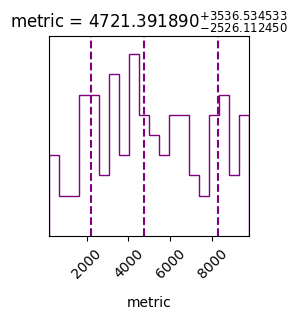

In [24]:
cornerplot(results_GP, title_fmt='.6f');

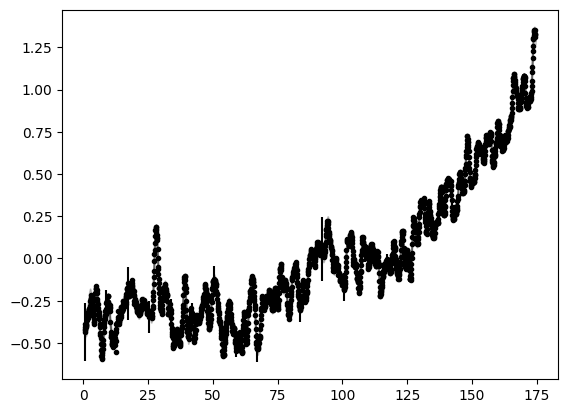

In [14]:
mean_metric = results_GP['samples'].mean()
time = data_air_masked['time_centered']
anomalies = data_air_masked['Annual_Anomaly']
anomalies_unc = data_air_masked['Annual_Anomaly_Unc']

res_kernel = kernels.ExpSquaredKernel(mean_metric)
res_gp = george.GP(res_kernel)
res_gp.compute(time, anomalies_unc)

pred_anomalies, pred_anomalies_unc = res_gp.predict(anomalies, time, return_var=True)

plt.errorbar(time, anomalies, yerr=anomalies_unc, fmt=".k", capsize=0, errorevery=100, zorder=0)
plt.fill_between(time, pred_anomalies - np.sqrt(pred_anomalies_unc), pred_anomalies + np.sqrt(pred_anomalies_unc), color="k", alpha=0.2)
plt.plot(time, pred_anomalies, "k", lw=1.5, alpha=0.5)
